# Montreal Financial & Macro Data Explorer

## Financial Performance Across Lightspeed, Canadian National Railway, and CAE

This notebook analyzes approximately five fiscal years of financial performance for three Montréal-connected public companies across technology, rail transportation, and aerospace.

The analysis focuses on revenue growth, profitability, balance-sheet structure, operating cash flow, and the Canadian macroeconomic environment.

Because the companies differ significantly in size and reporting currency, cross-company comparisons emphasize normalized growth measures, margins, and financial ratios rather than raw dollar values.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


project_root = Path.cwd().parent

database_path = project_root / "data" / "financial_data.db"


connection = sqlite3.connect(database_path)


financial_query = """
SELECT
    c.company_name,
    c.ticker,
    c.industry,
    c.currency,
    f.fiscal_year_end,
    f.revenue,
    f.operating_income,
    f.net_income,
    f.total_assets,
    f.total_liabilities,
    f.cash,
    f.operating_cash_flow
FROM financials AS f
JOIN companies AS c
    ON f.company_id = c.company_id
ORDER BY
    c.company_name,
    f.fiscal_year_end;
"""


financial_data = pd.read_sql_query(
    financial_query,
    connection
)


macro_data = pd.read_sql_query(
    """
    SELECT
        date,
        cpi,
        inflation_pct,
        policy_rate
    FROM macro_data
    ORDER BY date;
    """,
    connection
)


connection.close()


financial_data["fiscal_year_end"] = pd.to_datetime(
    financial_data["fiscal_year_end"]
)

macro_data["date"] = pd.to_datetime(
    macro_data["date"]
)


print("Financial rows:", len(financial_data))
print("Macro rows:", len(macro_data))

Financial rows: 15
Macro rows: 60


## Financial Metrics

To compare companies with different sizes and reporting currencies, the analysis focuses on normalized measures rather than raw dollar values.

The main metrics are:

- Revenue growth (%)
- Operating margin (%)
- Net profit margin (%)
- Liabilities as a percentage of total assets
- Operating cash-flow margin (%)

These measures allow more meaningful comparisons across technology, rail transportation, and aerospace.

In [2]:
import sys

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from metrics import add_financial_metrics


# Calculate the financial ratios
financial_data = add_financial_metrics(
    financial_data
)


# Add a fiscal-year column for easier plotting
financial_data["fiscal_year"] = (
    financial_data["fiscal_year_end"].dt.year
)


# Create an indexed revenue series
# Each company's first year is set equal to 100.
financial_data["revenue_index"] = (
    financial_data.groupby("company_name")["revenue"]
    .transform(
        lambda values: values / values.iloc[0] * 100
    )
)


columns_to_show = [
    "company_name",
    "fiscal_year",
    "revenue_growth_pct",
    "operating_margin_pct",
    "net_margin_pct",
    "liabilities_to_assets_pct",
    "operating_cash_flow_margin_pct"
]


financial_data[
    columns_to_show
].round(2)

,company_name,fiscal_year,revenue_growth_pct,operating_margin_pct,net_margin_pct,liabilities_to_assets_pct,operating_cash_flow_margin_pct
0,CAE,2021,NaN,1.62,-1.59,63.28,12.29
1,CAE,2022,13.06,8.43,4.45,57.34,12.40
2,CAE,2023,18.96,11.62,5.78,56.03,10.18
3,CAE,2024,6.79,-4.33,-6.92,56.25,13.24
4,CAE,2025,9.93,15.49,8.81,55.63,19.04
5,Canadian National Railway,2021,NaN,38.79,33.84,53.14,48.15
6,Canadian National Railway,2022,18.17,39.98,29.92,57.79,38.97
7,Canadian National Railway,2023,-1.63,39.20,33.43,61.80,41.39
8,Canadian National Railway,2024,1.30,36.65,26.09,63.11,39.30
9,Canadian National Railway,2025,1.51,38.07,27.28,63.17,40.74


## Revenue Growth

Raw revenue values are not directly comparable across the three companies because Lightspeed reports in USD while CN and CAE report in CAD. To make the comparison more meaningful, revenue is indexed so that each company's 2021 revenue equals 100.

From 2021 to 2025:

- **Lightspeed** experienced the strongest relative revenue expansion, with its revenue index rising from 100 to approximately 486.
- **CAE** increased from 100 to approximately 158.
- **Canadian National Railway** increased more gradually from 100 to approximately 120.

Lightspeed therefore shows the strongest growth profile, while CN displays the more mature and stable revenue pattern.

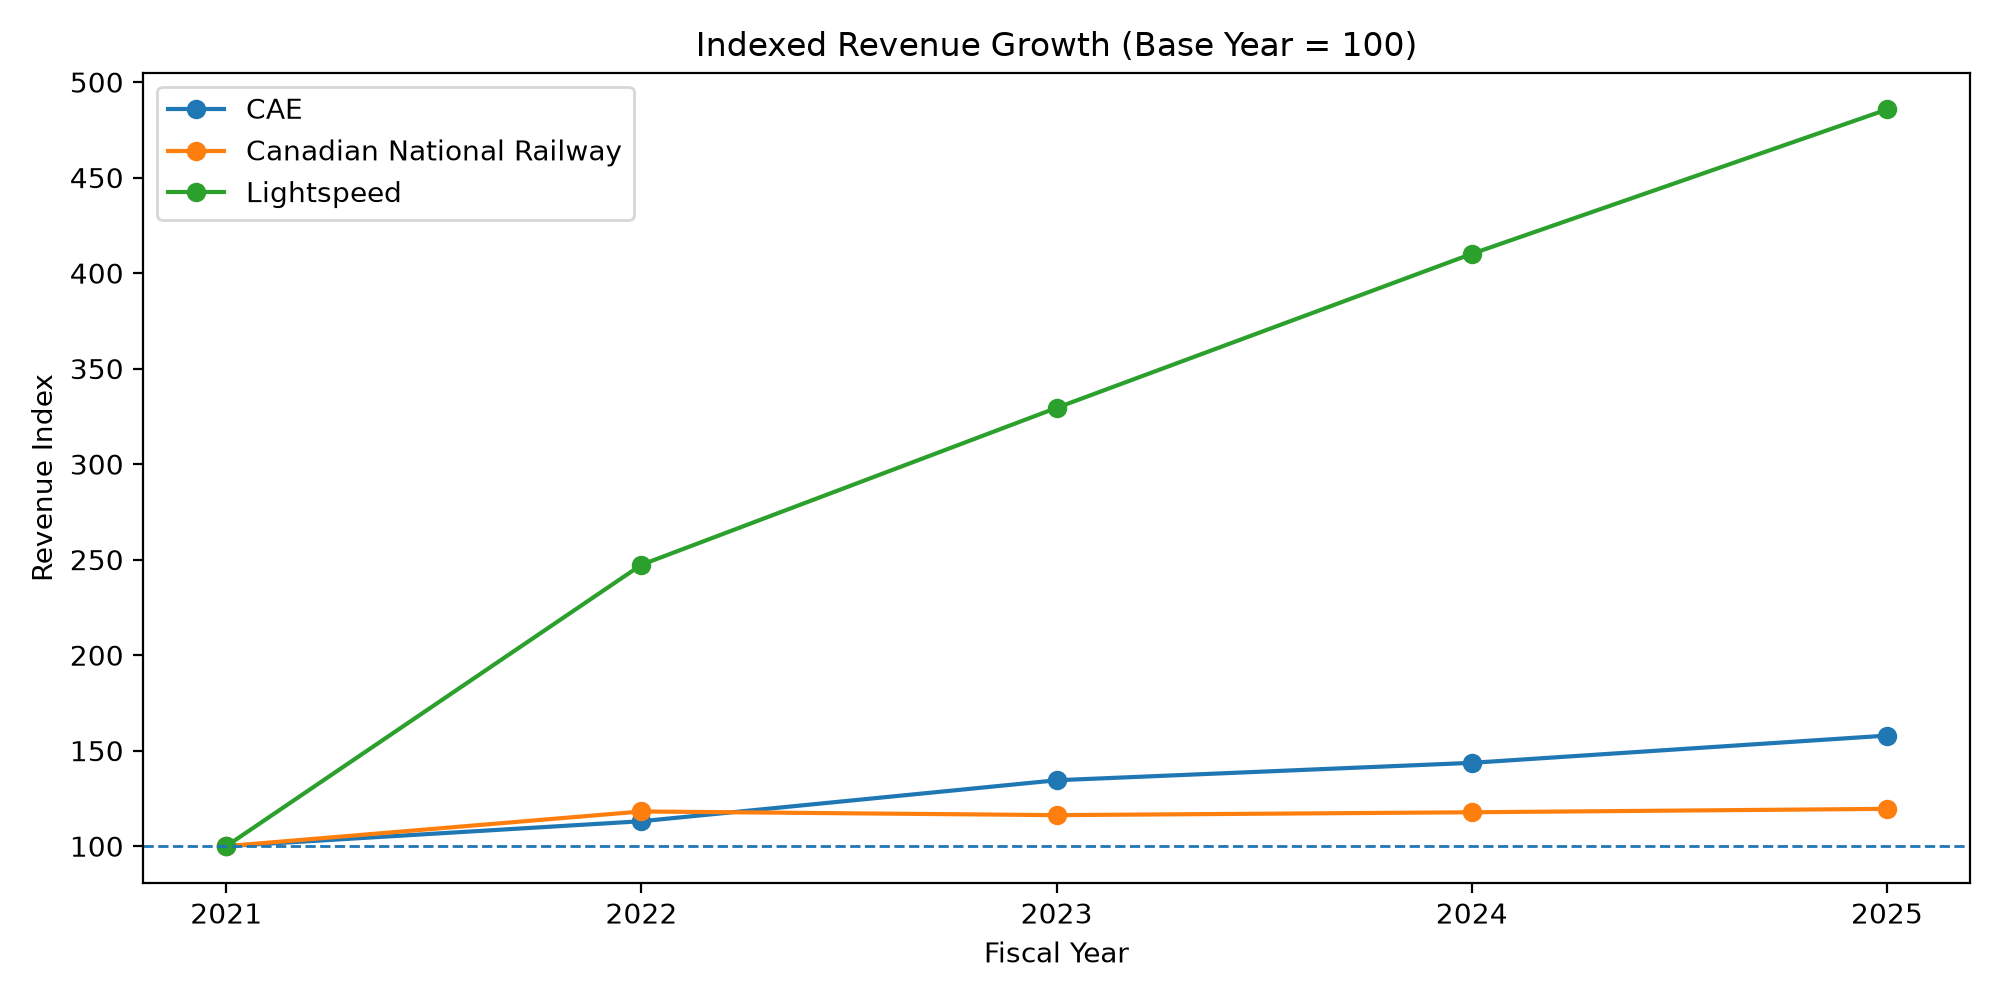

In [3]:
from IPython.display import Image, display


display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "01_indexed_revenue_growth.png"
        )
    )
)

## Profitability

Operating and net profit margins show clear differences across the three companies.

- **Canadian National Railway** maintained the strongest and most stable profitability, with operating margins staying around the high-30% range throughout the period.
- **CAE** showed more moderate profitability and greater year-to-year variation, including a negative operating margin in 2024 before recovering strongly in 2025.
- **Lightspeed** remained unprofitable across all five years. Its margins were especially weak in 2023, although some improvement appeared in 2024.

These differences reflect very different business models and stages of development, so the ratios are more informative than comparing raw profit amounts.

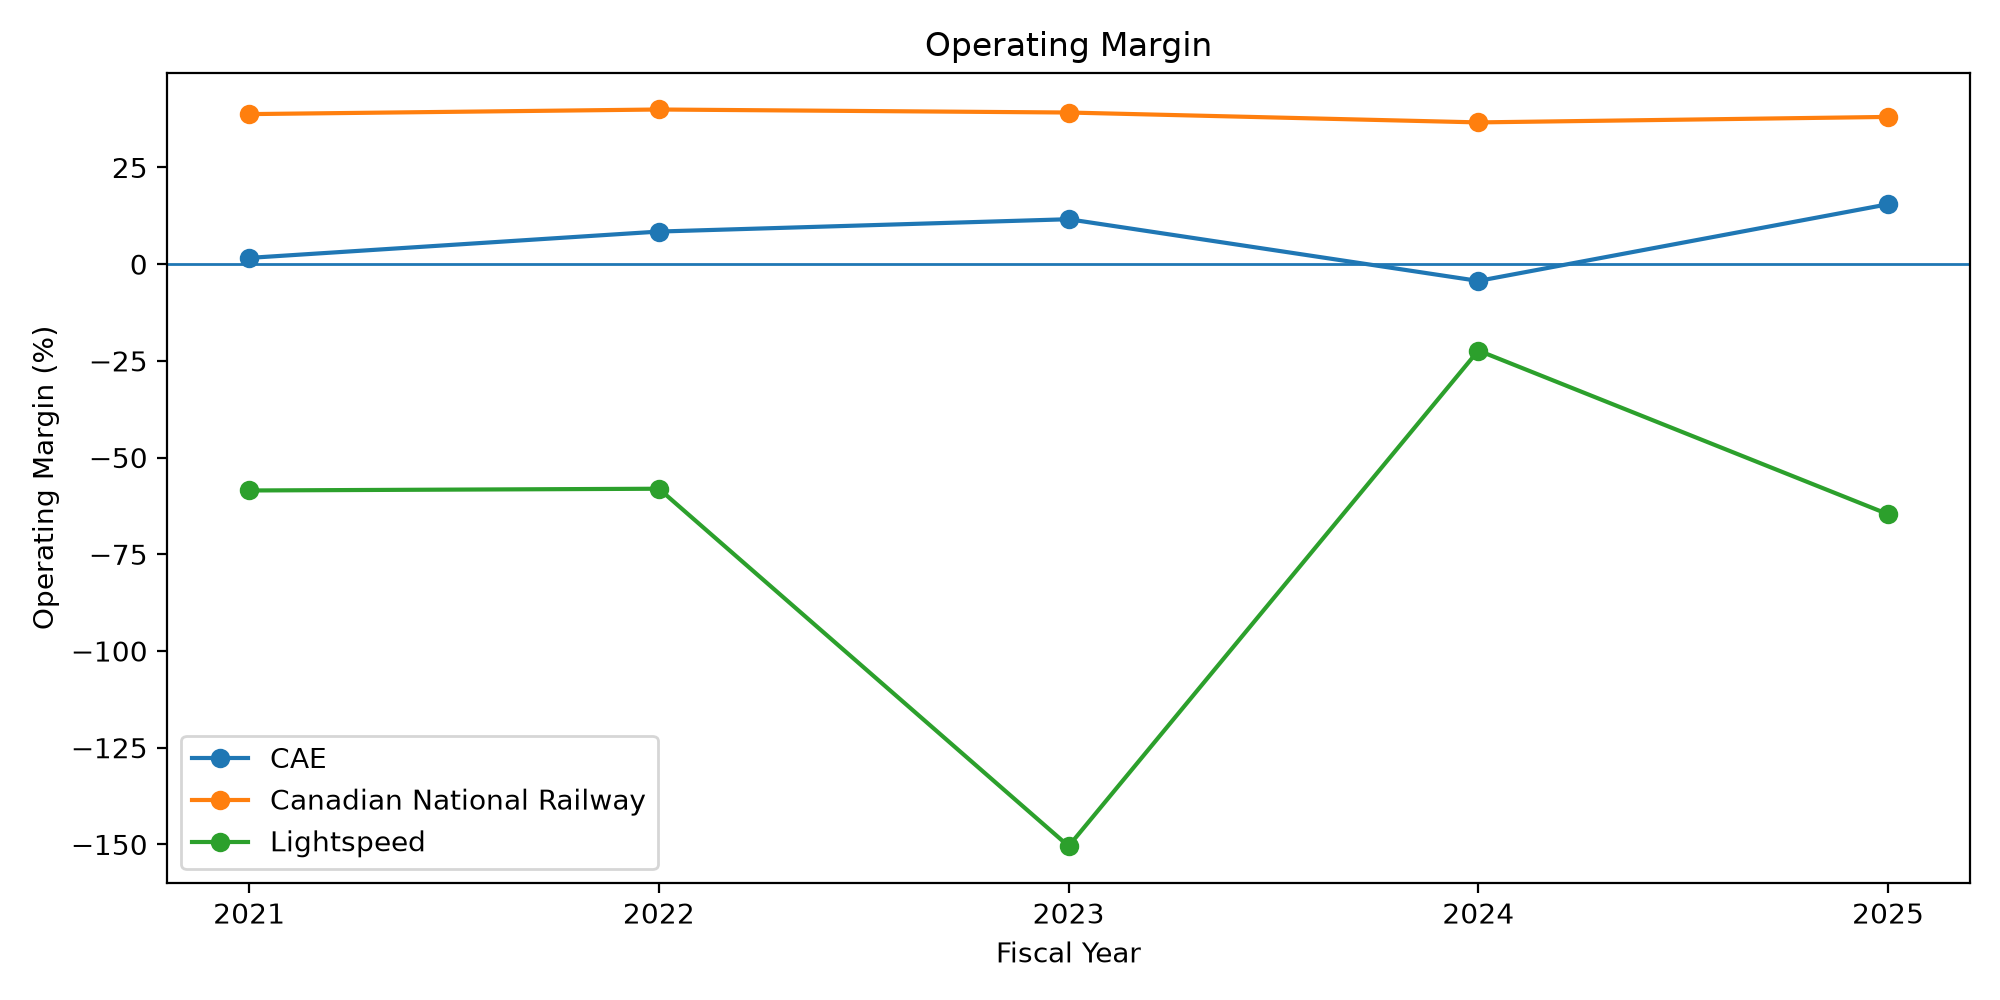

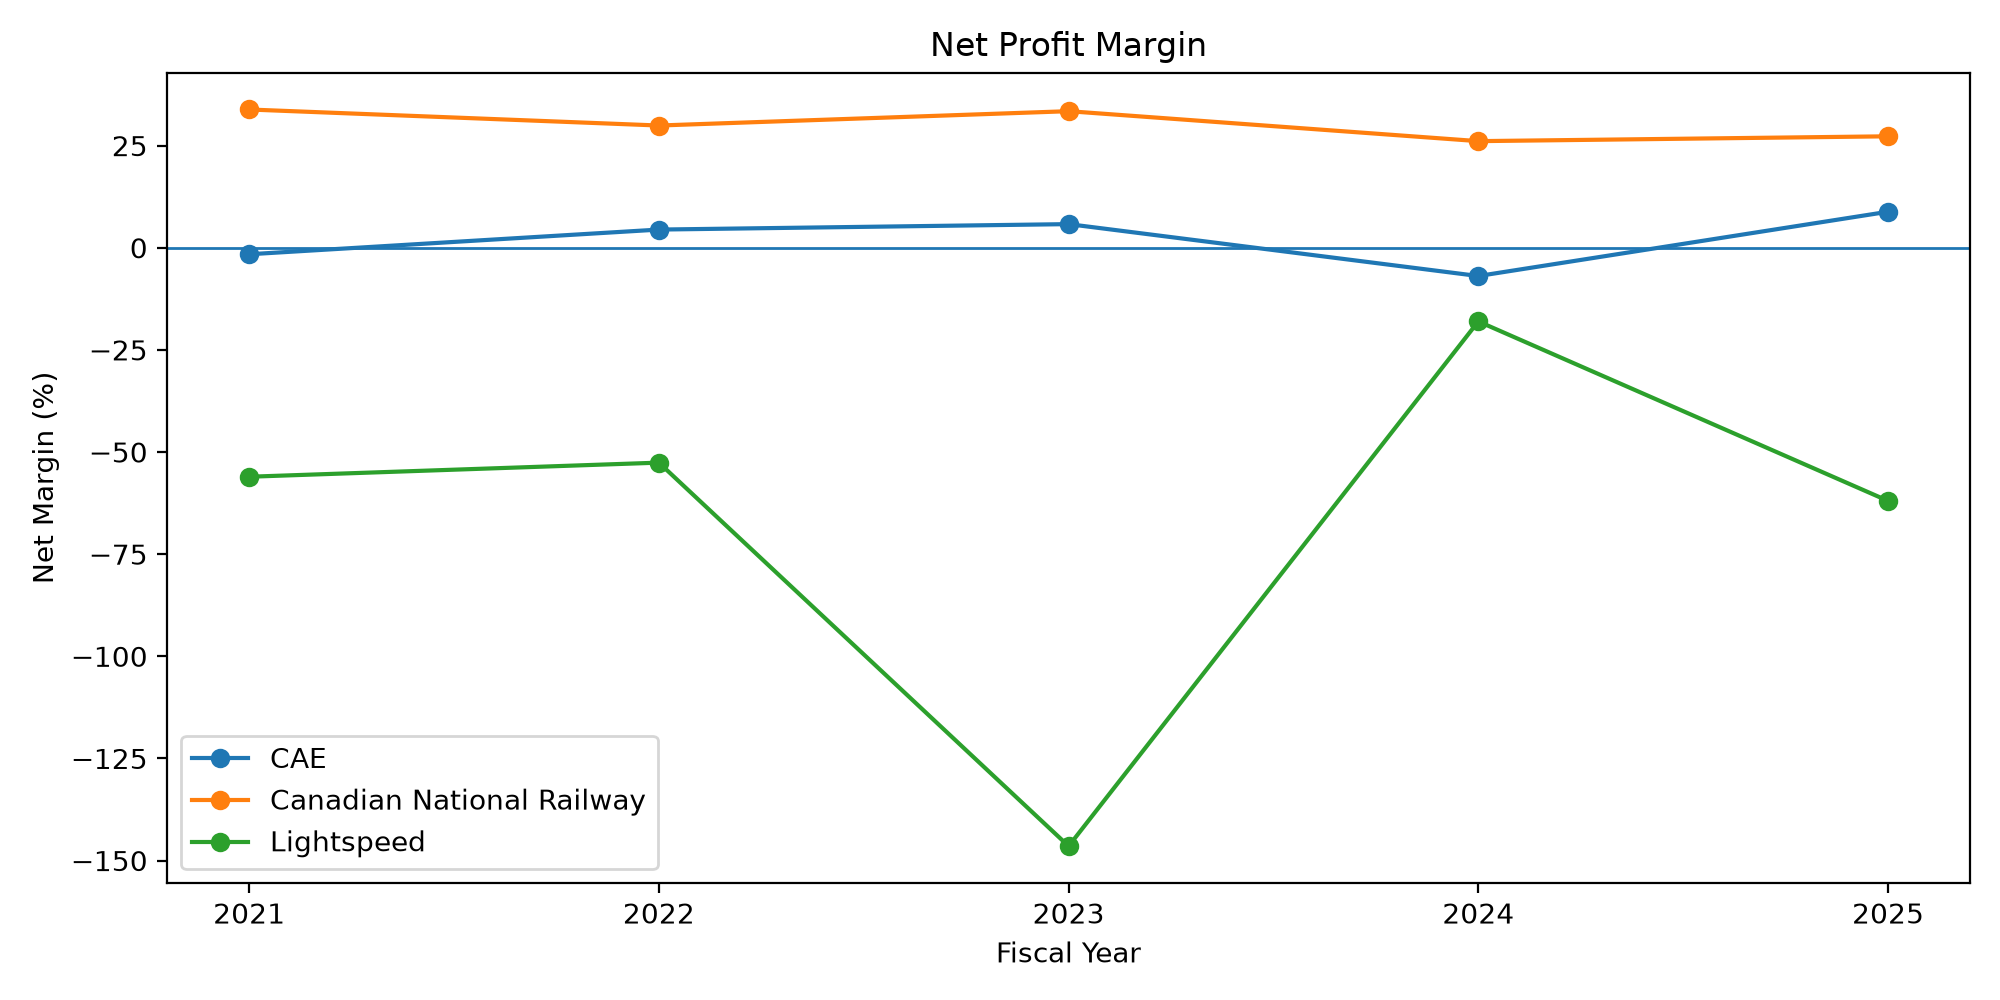

In [4]:
display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "03_operating_margin.png"
        )
    )
)

display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "04_net_margin.png"
        )
    )
)

## Financial Health and Cash Flow

The balance-sheet and cash-flow ratios provide another view of financial health across the three companies.

### Balance-Sheet Structure

- **Canadian National Railway** had the highest liabilities-to-assets ratio, increasing from approximately 53% in 2021 to 63% in 2025.
- **CAE** remained relatively stable, with liabilities representing roughly 56% of assets in recent years.
- **Lightspeed** had a much lower liabilities-to-assets ratio, generally below 9%, indicating a very different balance-sheet structure from CN and CAE.

A higher liabilities-to-assets ratio does not automatically indicate poor financial health. The companies operate in very different industries and have different capital structures.

### Operating Cash Flow

- **CN** consistently generated strong positive operating cash flow relative to revenue.
- **CAE** also maintained positive operating cash-flow margins and improved to approximately 19% in 2025.
- **Lightspeed** generated negative operating cash flow throughout the period, but its operating cash-flow margin improved substantially from approximately -42% in 2021 to about -3% in 2025.

The improvement in Lightspeed's operating cash-flow margin suggests that its cash-generation profile moved closer to break-even even though profitability remained negative.

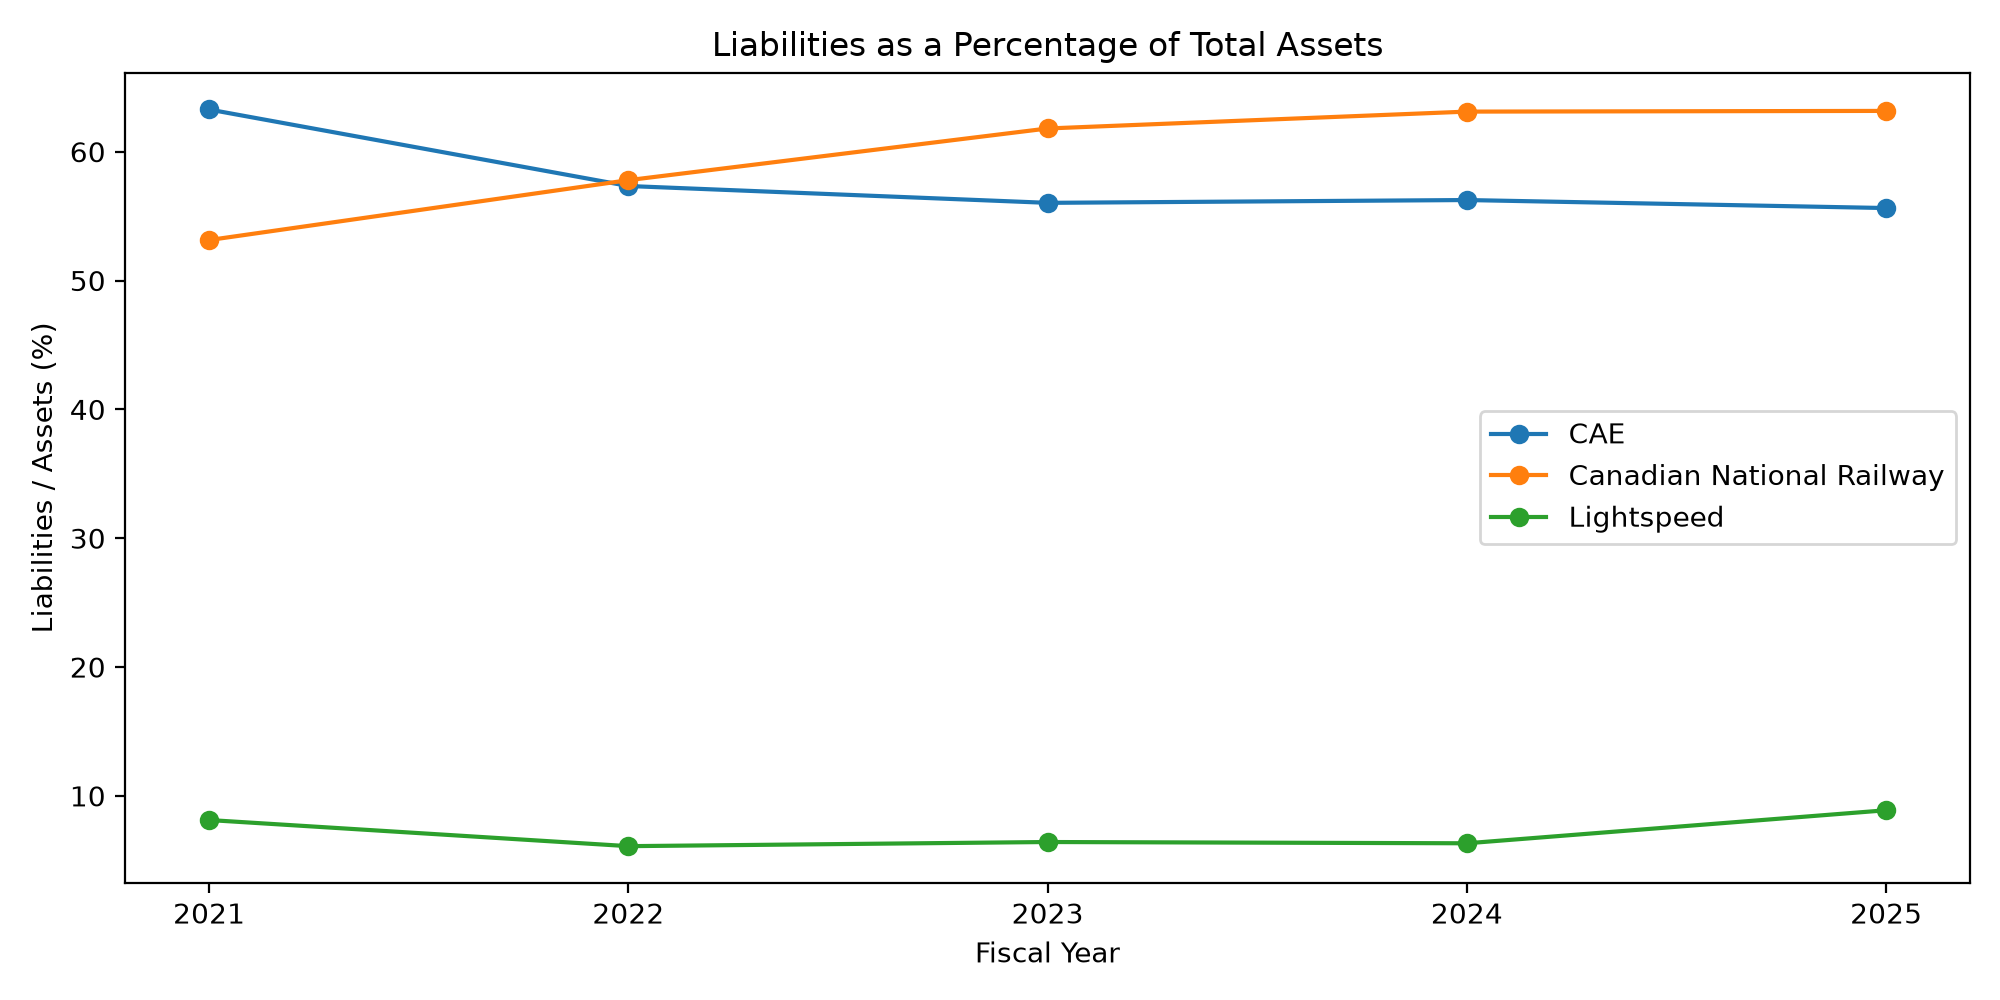

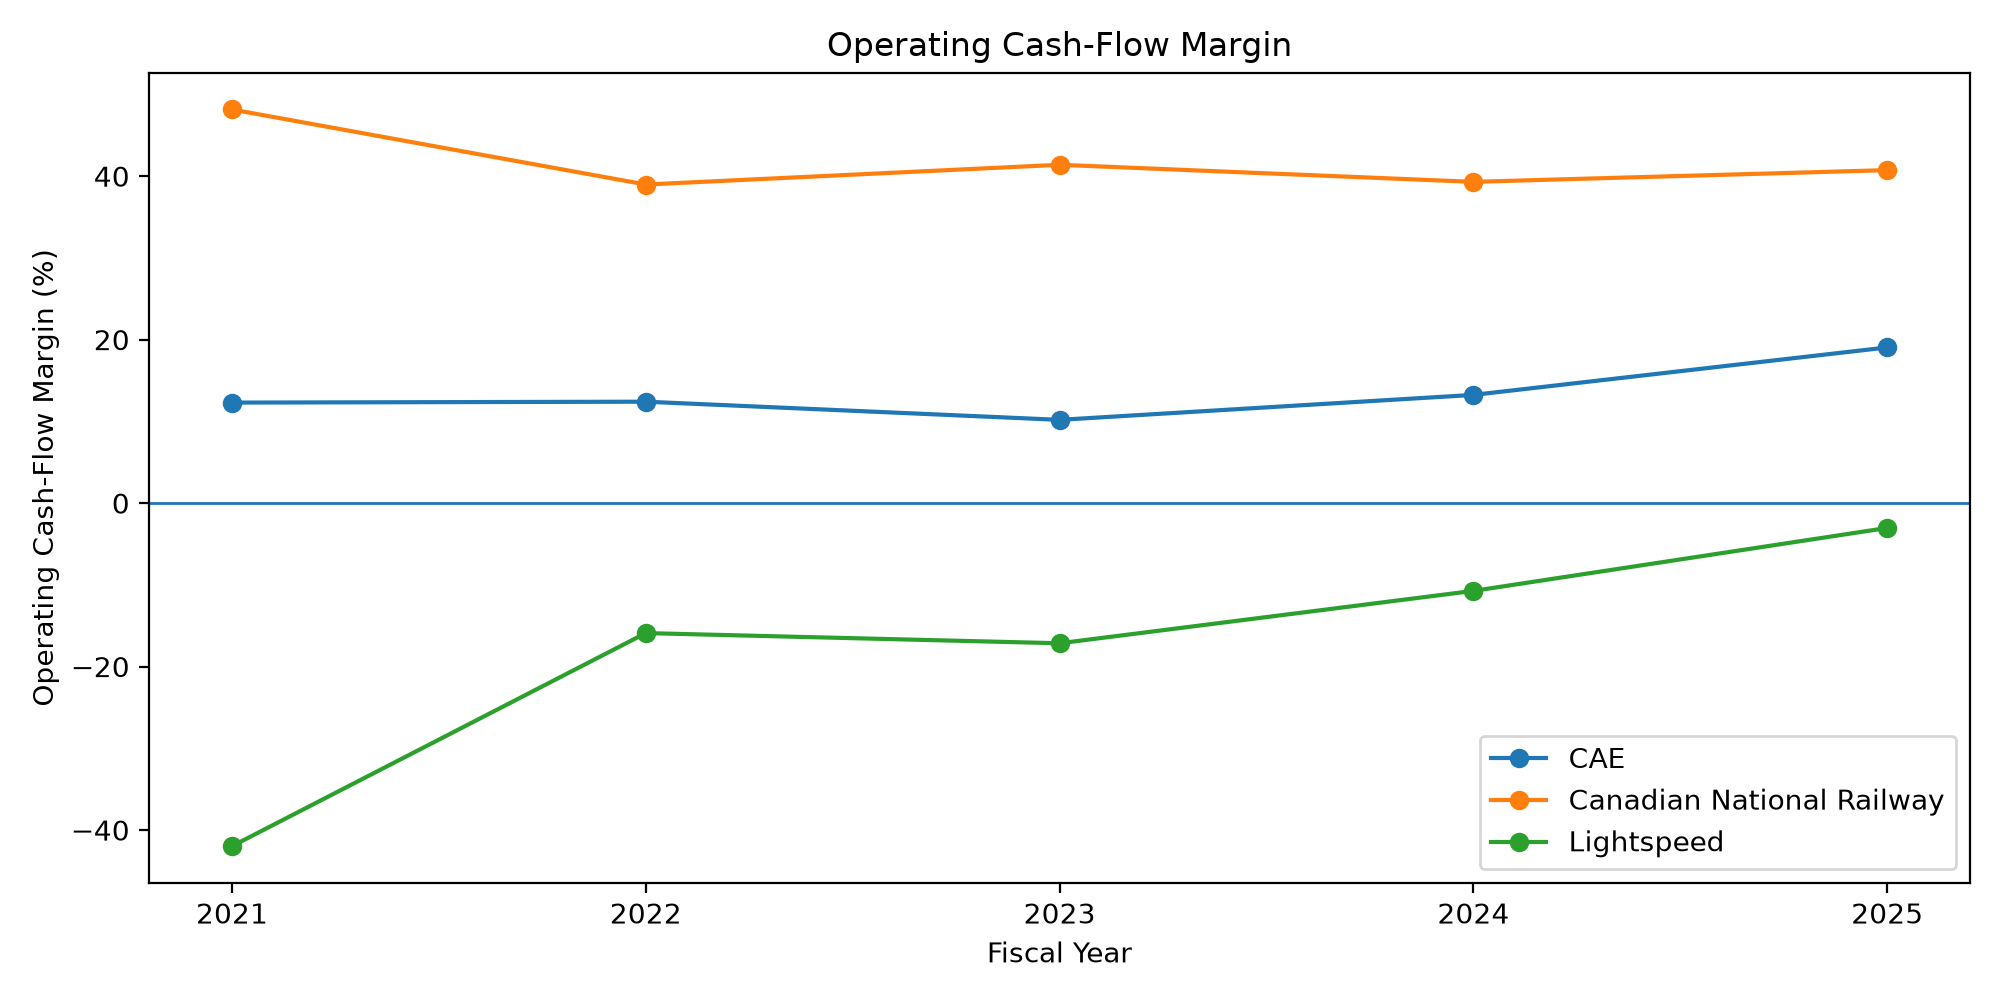

In [5]:
display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "05_liabilities_to_assets.png"
        )
    )
)

display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "06_operating_cash_flow_margin.png"
        )
    )
)

## Canadian Macroeconomic Environment

Canadian inflation and monetary policy changed substantially during the period covered by this analysis.

- Inflation rose earlier in the period and later moderated toward lower levels.
- The Bank of Canada increased its policy interest rate as monetary conditions tightened, before rates began declining again later in the sample.
- By the end of 2025, the policy rate in the dataset was 2.25%, while year-over-year inflation was approximately 2.36%.

These indicators provide economic context for the company results, but the analysis does not assume that changes in inflation or interest rates directly caused changes in company revenue, profitability, or cash flow. Each company is also affected by industry-specific and firm-specific factors.

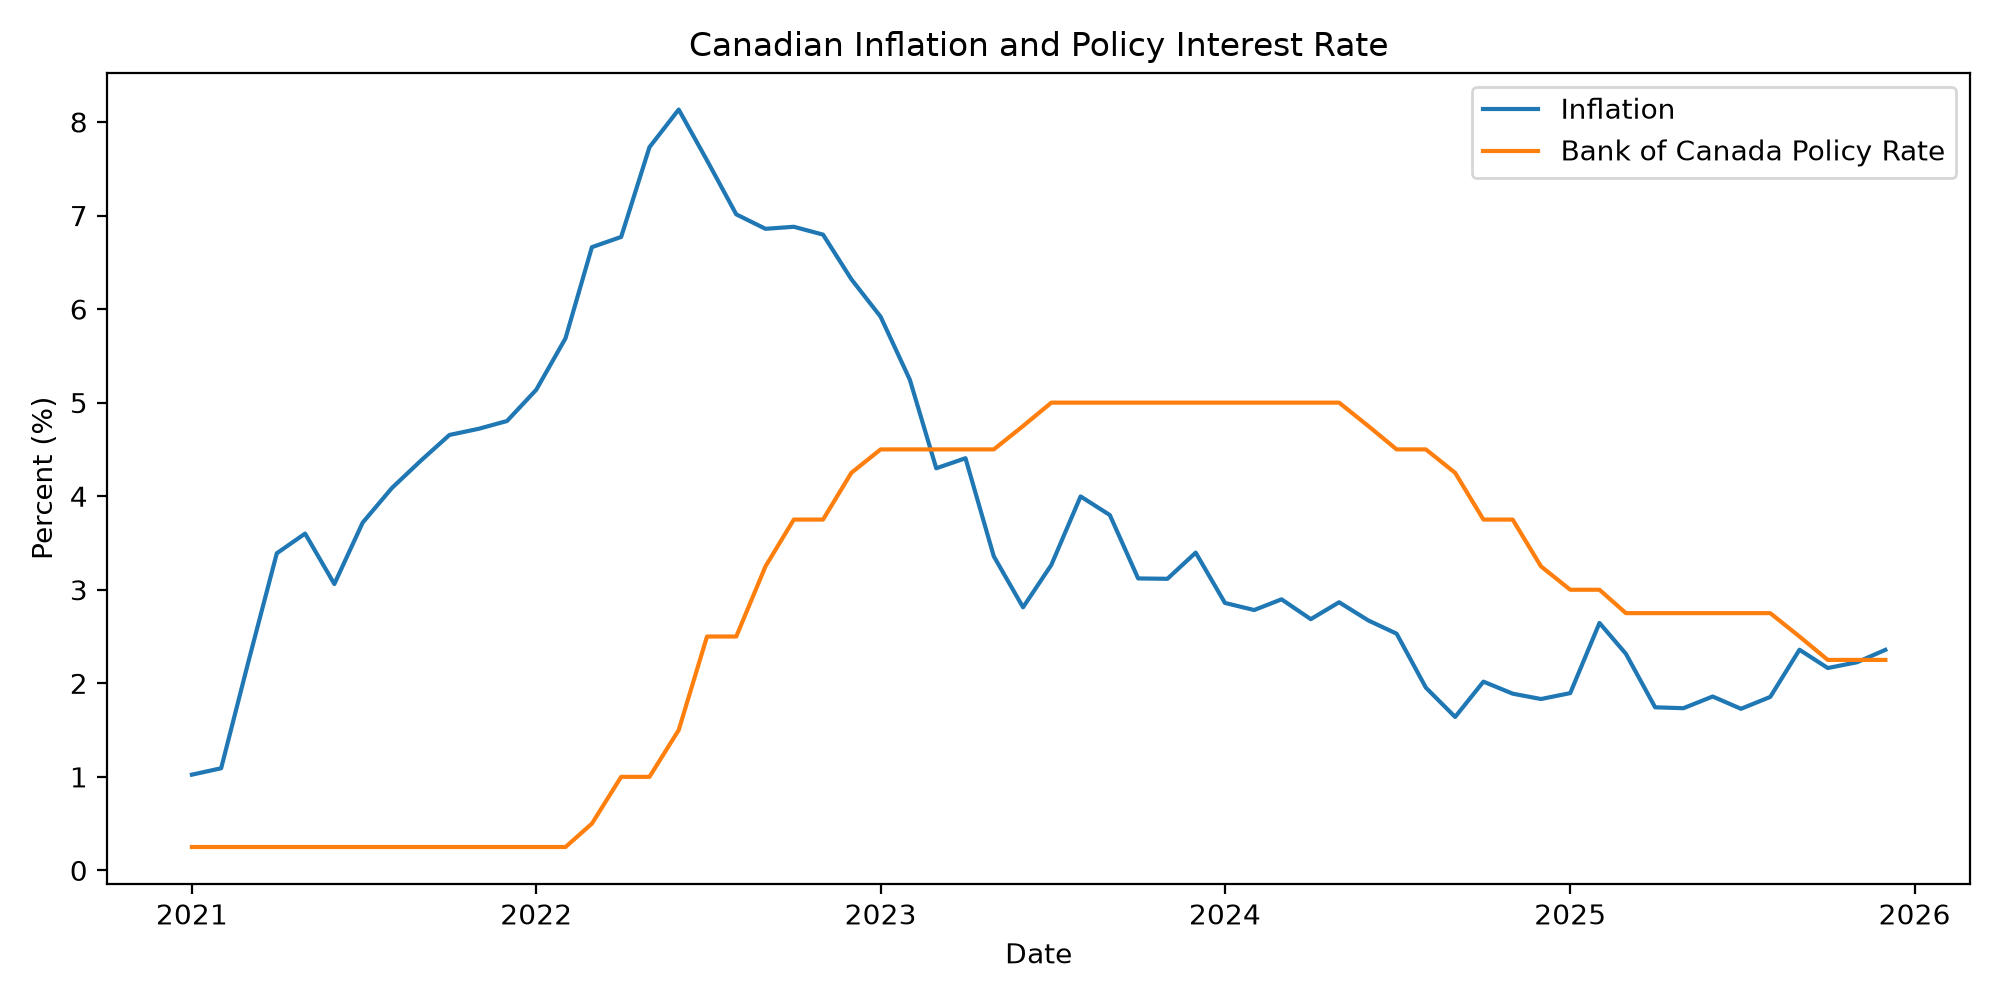

In [6]:
display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "07_canadian_macro_environment.png"
        )
    )
)

## Final Comparison and Key Findings

The three companies followed very different financial paths over the five-year period.

### Growth

**Lightspeed experienced the strongest relative revenue growth.** Its indexed revenue increased from 100 in 2021 to approximately 486 in 2025. However, its annual growth rate gradually slowed as the company became larger.

**CAE** showed steady overall revenue expansion, while **Canadian National Railway** displayed the most mature and stable revenue profile.

### Profitability

**Canadian National Railway maintained the strongest profitability** throughout the period. Its operating margin remained around the high-30% range, substantially above the other two companies.

**CAE** generated positive margins in most years but experienced a significant deterioration in 2024 before recovering strongly in 2025.

**Lightspeed** remained unprofitable over the full period despite its rapid revenue growth.

### Cash Generation

CN consistently generated the strongest operating cash flow relative to revenue.

CAE also maintained positive operating cash-flow margins throughout the period.

Lightspeed's operating cash flow remained negative, but its operating cash-flow margin improved considerably from approximately -42% in 2021 to about -3% in 2025.

### Balance-Sheet Structure

CN's liabilities-to-assets ratio increased over the period and reached approximately 63% in 2025.

CAE maintained a ratio in the mid-50% range in recent years.

Lightspeed maintained a substantially lower liabilities-to-assets ratio, reflecting a different capital structure from the two more asset-intensive companies.

### Overall

The results illustrate why financial performance should not be evaluated using a single measure.

- **Lightspeed** had the strongest growth but the weakest profitability.
- **CN** combined slower growth with strong profitability and cash generation.
- **CAE** occupied a middle position, with moderate growth and profitability but greater year-to-year variation.

The comparison also highlights how business models and industry characteristics can produce very different financial profiles.

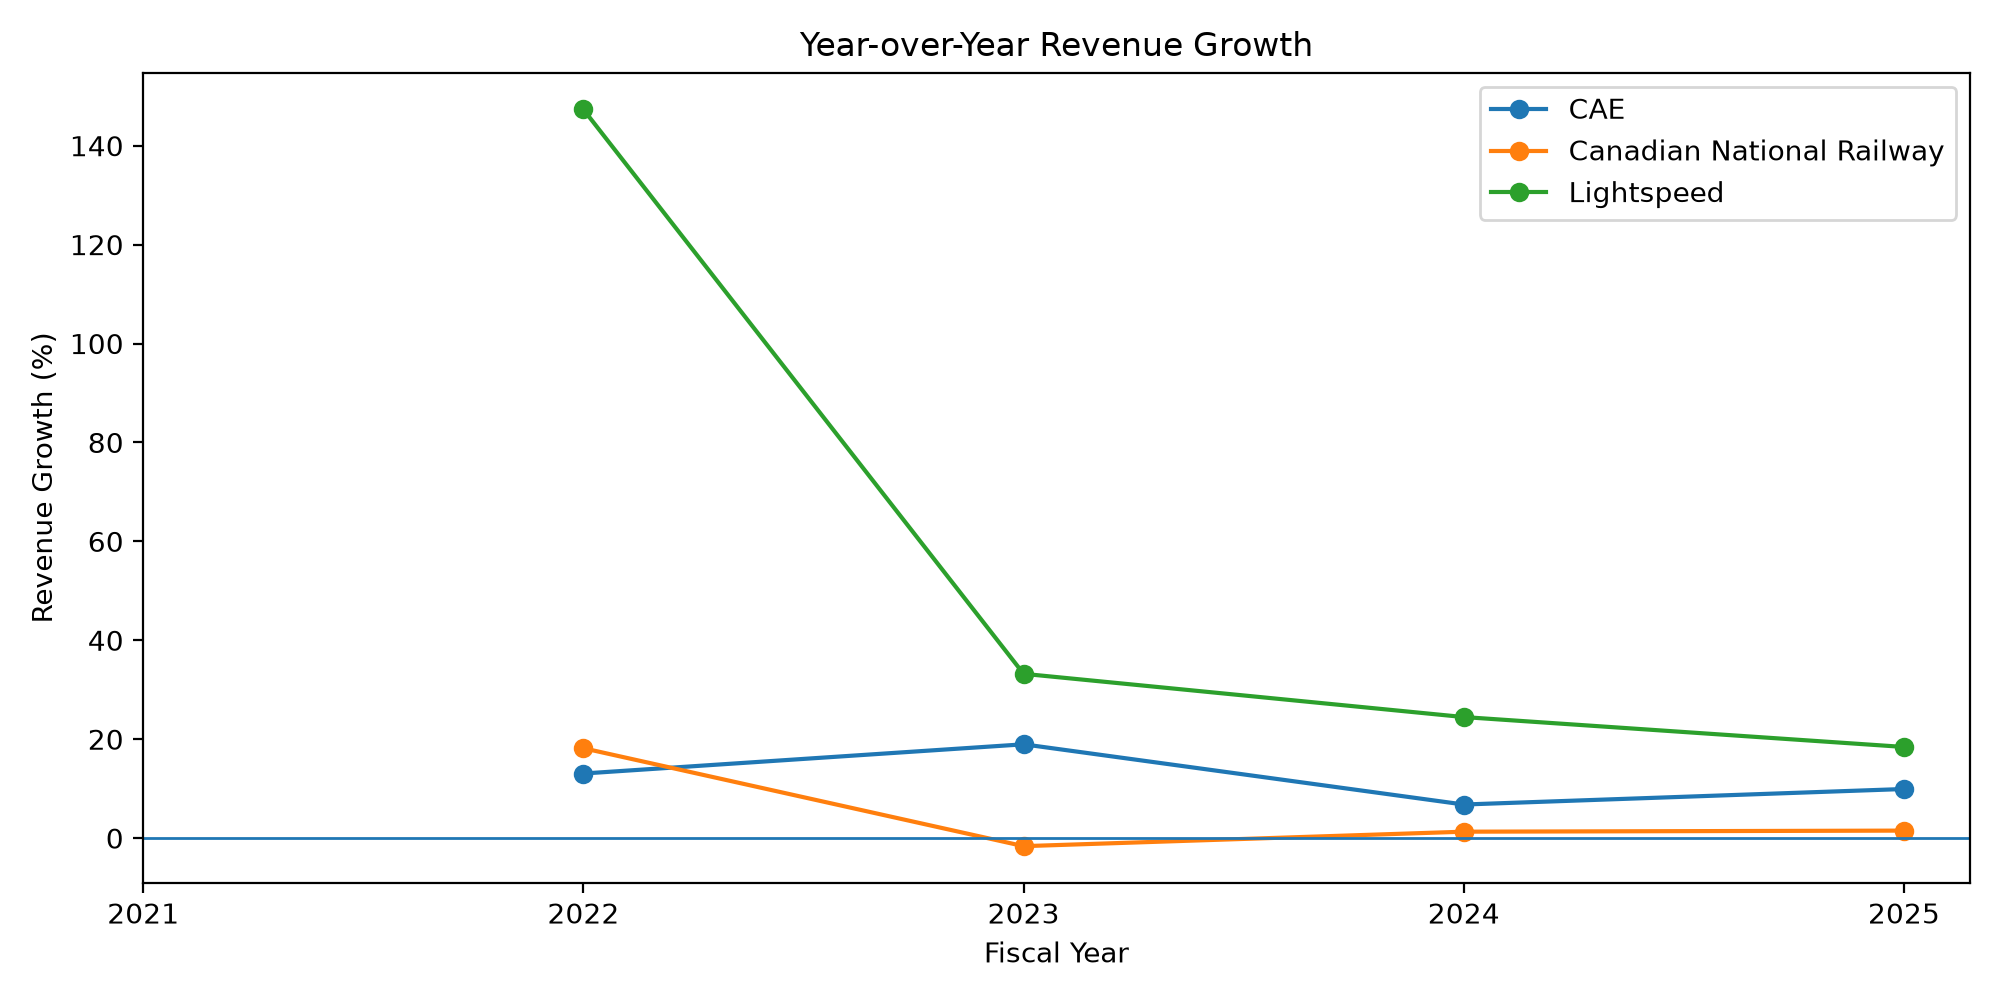

In [7]:
display(
    Image(
        filename=str(
            project_root
            / "outputs"
            / "charts"
            / "02_revenue_growth.png"
        )
    )
)

## Limitations

This analysis has several important limitations.

1. **Different reporting currencies**  
   Lightspeed reports in USD, while Canadian National Railway and CAE report in CAD. For this reason, cross-company comparisons emphasize growth rates, indexes, and financial ratios rather than raw dollar amounts.

2. **Different fiscal year-ends**  
   Lightspeed and CAE have fiscal years ending around March 31, while CN's fiscal year ends December 31. A given fiscal year therefore does not represent exactly the same economic period for all three companies.

3. **Different industries and business models**  
   Technology, rail transportation, and aerospace have very different cost structures, capital requirements, growth profiles, and financing needs. Ratios should therefore be interpreted in context rather than treated as directly equivalent measures of quality.

4. **Financial-data availability**  
   Most company observations were collected from SEC XBRL Company Facts. Where the SEC series contained gaps for CN, verified values from CN's published annual financial statements were used to supplement the dataset.

5. **Accounting differences**  
   The companies do not necessarily use identical accounting frameworks or financial-statement classifications. Although the selected metrics were standardized conceptually, some differences in reporting definitions may remain.

6. **Macroeconomic interpretation**  
   Inflation and Bank of Canada policy-rate data provide economic context only. This analysis does not establish that changes in macroeconomic variables caused changes in company financial performance.

7. **Small sample period**  
   The analysis covers approximately five fiscal years. It is useful for identifying recent trends but is not sufficient to characterize complete long-term business cycles.

## Conclusion

Across the selected Montréal-connected companies, the analysis reveals a clear trade-off between growth, profitability, and financial structure.

Lightspeed recorded the strongest relative revenue expansion but remained unprofitable and cash-flow negative. Canadian National Railway showed the strongest profitability and operating cash generation, consistent with a mature and capital-intensive business. CAE displayed moderate growth and a more variable profitability pattern, including a notable decline in 2024 followed by a strong recovery in 2025.

Overall, normalized financial metrics provide a more meaningful basis for cross-industry comparison than raw financial statement values. The Canadian macroeconomic environment provides additional context, but company-specific and industry-specific factors remain essential when interpreting the results.